# COVID SEVERITY PREDICTION

In [1]:
pip install shap==0.44.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.7/535.7 kB 2.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import pickle
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import shap
%matplotlib inline


In [3]:
data = pd.read_excel("data_target_Severity.xlsx")
data

,Derivation cohort,LOS,Death,Black,White,Asian,Latino,MI,PVD,CHF,...,Sodium,Glucose,AST,ALT,WBC,Lympho,Ferritin,CrctProtein,Troponin,Severity
0,1,1,0,0,0,0,0,0,0,0,...,135.000000,112.000000,26.000000,14.000000,5.600000,1.400000,0.000000,0.499900,0.010000,3
1,1,2,1,0,1,0,0,0,1,0,...,137.000000,265.000000,85.000000,32.000000,12.200000,0.300000,885.000000,14.900000,1.200000,7
2,1,2,1,0,1,0,0,0,1,1,...,140.000000,121.000000,32.000000,18.000000,6.100000,0.500000,629.000000,33.900000,0.039731,7
3,1,15,0,1,0,0,0,1,0,0,...,132.000000,183.750167,44.000000,17.000000,3.700000,0.500000,816.000000,18.400000,0.050000,9
4,1,9,0,1,0,0,0,0,0,0,...,149.000000,182.940957,38.000000,28.000000,5.700000,1.400000,1691.000000,11.600000,0.010000,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4706,0,4,0,0,0,1,0,0,0,0,...,139.000000,97.000000,23.000000,24.000000,10.300000,1.000000,295.000000,1.800000,0.010000,4
4707,0,2,0,0,0,0,1,0,1,0,...,136.000000,160.935077,40.000000,30.000000,4.100000,1.200000,1165.000000,3.100000,0.010000,2
4708,0,5,0,0,0,0,0,0,1,0,...,136.000000,153.000000,26.000000,16.000000,7.400000,1.000000,239.000000,0.499900,0.000000,1
4709,0,5,0,1,0,0,0,0,1,0,...,137.000000,131.000000,31.000000,33.000000,7.600000,1.800000,1185.000000,8.600000,0.010000,3


In [4]:
data.columns

Index(['Derivation cohort', 'LOS', 'Death', 'Black', 'White', 'Asian',
       'Latino', 'MI', 'PVD', 'CHF', 'CVD', 'DEMENT', 'COPD', 'DM Complicated',
       'DM Simple', 'Renal Disease', 'All CNS', 'Pure CNS', 'Stroke',
       'Seizure', 'OldSyncope', 'OldOtherNeuro', 'OtherBrnLsn', 'Age.1',
       'AgeScore', 'OsSats', 'Temp', 'MAP', 'Ddimer', 'Plts', 'PltsScore',
       'INR', 'BUN', 'Creatinine', 'CrtnScore', 'Sodium', 'Glucose', 'AST',
       'ALT', 'WBC', 'Lympho', 'Ferritin', 'CrctProtein', 'Troponin',
       'Severity'],
      dtype='object')

In [5]:
# Renaming columns
data = data.rename(columns={
    'LOS': 'Length_of_stay',
    'MI': 'Myocardial_infarction',
    'PVD': 'Per_vascular_dis',
    'CHF': 'Cong_heart_failure',
    'CVD': 'Cardiovascular_dis',
    'DEMENT': 'Dementia',
    'COPD': 'Chronic_obst_pulm_dis',
    'DM Complicated': 'Diabetes_mel_complicated',
    'DM Simple': 'Diabetes_mel_simple',
    'Renal Disease': 'Renal_dis',
    'All CNS': 'All_CNS',
    'Pure CNS': 'Pure_CNS',
    'OldOtherNeuro': 'Other_neuro_dis',
    'OtherBrnLsn': 'Other_brain_lesions',
    'Age.1': 'Age_number',
    'AgeScore': 'Age_category',
    'OsSats': 'Oxygen_sat',
    'Temp': 'Temperature',
    'MAP': 'Mean_art_press',
    'Plts': 'Platelets',
    'INR': 'Inter_norm_ratio',
    'BUN': 'Blood_urea_nitr',
    'WBC': 'White_blood_cells',
    'CrctProtein': 'CRP'
})


In [6]:
original_data = data.copy()
data_copy = data.copy()


In [7]:
data.columns

Index(['Derivation cohort', 'Length_of_stay', 'Death', 'Black', 'White',
       'Asian', 'Latino', 'Myocardial_infarction', 'Per_vascular_dis',
       'Cong_heart_failure', 'Cardiovascular_dis', 'Dementia',
       'Chronic_obst_pulm_dis', 'Diabetes_mel_complicated',
       'Diabetes_mel_simple', 'Renal_dis', 'All_CNS', 'Pure_CNS', 'Stroke',
       'Seizure', 'OldSyncope', 'Other_neuro_dis', 'Other_brain_lesions',
       'Age_number', 'Age_category', 'Oxygen_sat', 'Temperature',
       'Mean_art_press', 'Ddimer', 'Platelets', 'PltsScore',
       'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'CrtnScore',
       'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho',
       'Ferritin', 'CRP', 'Troponin', 'Severity'],
      dtype='object')

# Vizualizácia vplyvu vybraných atribútov na závažnosť Covidu-19

<Axes: xlabel='Severity', ylabel='Age_number'>

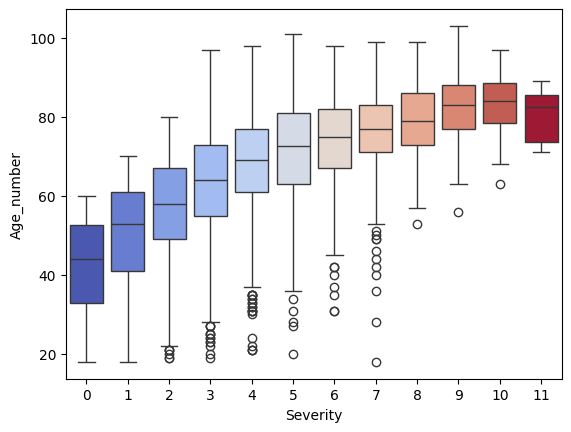

In [8]:
sns.boxplot(x="Severity", y="Age_number", data=data, hue="Severity", palette="coolwarm", legend=False)

<Axes: xlabel='Severity', ylabel='Blood_urea_nitr'>

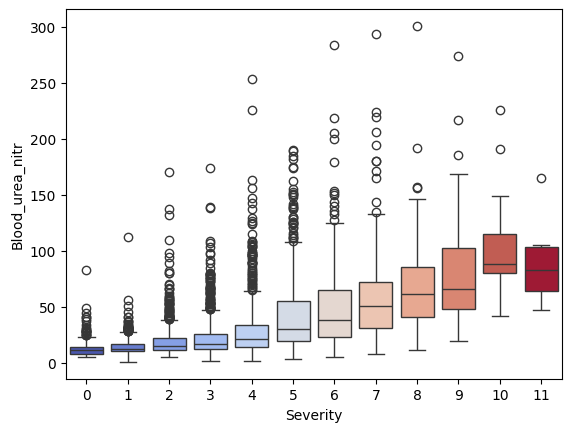

In [9]:
sns.boxplot(x="Severity", y="Blood_urea_nitr", data=data, hue="Severity", palette="coolwarm", legend=False)

<Axes: xlabel='Severity', ylabel='Ddimer'>

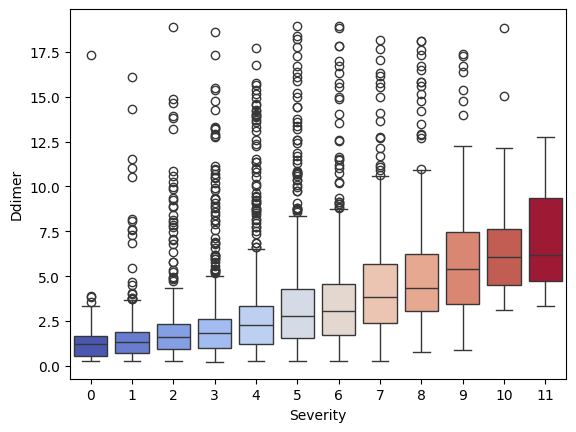

In [10]:
sns.boxplot(x="Severity", y="Ddimer", data=data, hue="Severity", palette="coolwarm", legend=False)

<Axes: xlabel='Severity', ylabel='Creatinine'>

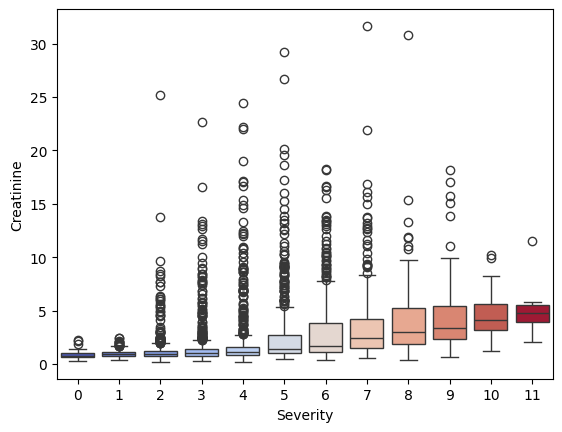

In [11]:
sns.boxplot(x="Severity", y="Creatinine", data=data, hue="Severity", palette="coolwarm", legend=False)

<Axes: xlabel='Severity', ylabel='Mean_art_press'>

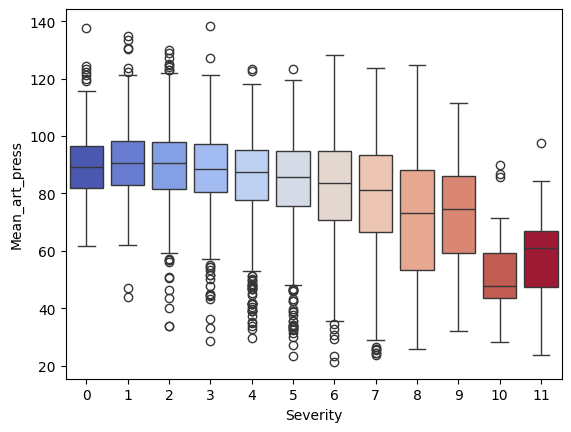

In [12]:
sns.boxplot(x="Severity", y="Mean_art_press", data=data, hue="Severity", palette="coolwarm", legend=False)

<Axes: xlabel='Severity', ylabel='Oxygen_sat'>

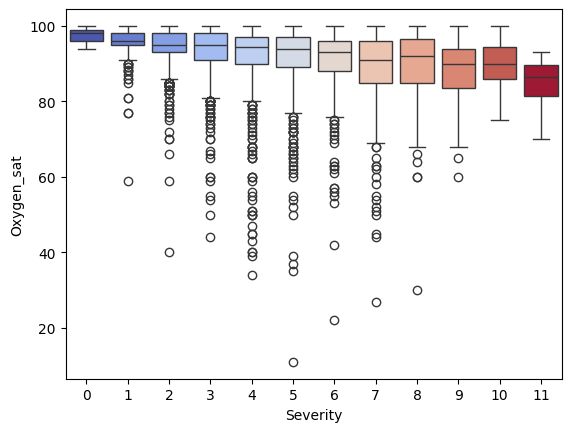

In [13]:
sns.boxplot(x="Severity", y="Oxygen_sat", data=data, hue="Severity", palette="coolwarm", legend=False)

# FEATURE IMPORTANCE

In [14]:
numeric_features = data.columns[data.nunique() > 10]
numeric_features = numeric_features.drop("Severity")

print("Columnns that contain more than 10 values:\n", numeric_features)
print("Number of nuemrical features:", numeric_features.size)

Columnns that contain more than 10 values:
 Index(['Length_of_stay', 'Age_number', 'Oxygen_sat', 'Temperature',
       'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio',
       'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT',
       'White_blood_cells', 'Lympho', 'Ferritin', 'CRP', 'Troponin'],
      dtype='object')
Number of nuemrical features: 19


In [15]:
categorical_features = data.columns[data.nunique() <=4]

print("Columnns that contain less than 10 values:\n", categorical_features)
print("Number of categorical features:", categorical_features.size)

Columnns that contain less than 10 values:
 Index(['Derivation cohort', 'Death', 'Black', 'White', 'Asian', 'Latino',
       'Myocardial_infarction', 'Per_vascular_dis', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_category', 'PltsScore',
       'CrtnScore'],
      dtype='object')
Number of categorical features: 25


In [16]:
categorical_features

Index(['Derivation cohort', 'Death', 'Black', 'White', 'Asian', 'Latino',
       'Myocardial_infarction', 'Per_vascular_dis', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_category', 'PltsScore',
       'CrtnScore'],
      dtype='object')

CHI - square test for categorical input and categorical output


Chi-Squared Test Results:
Feature	P-Value
Age_category	0.0
CrtnScore	0.0
Death	1.712318427980503e-139
PltsScore	4.716905170888163e-77
Pure_CNS	3.872532314311079e-09
All_CNS	6.034185007447569e-08
Per_vascular_dis	0.0030180217228457846
Derivation cohort	0.029820511627501836




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



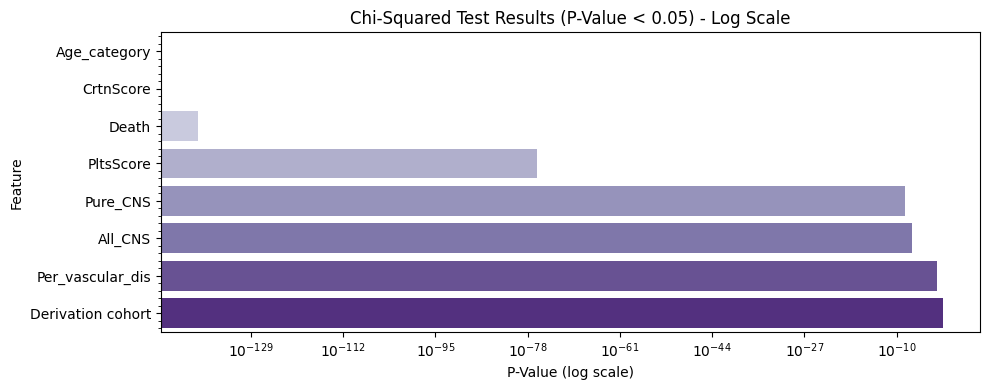

In [18]:
df = pd.DataFrame(data)

# Encode these categorical features
le = LabelEncoder()
for column in categorical_features:
    if df[column].dtype == 'object' or column in categorical_features:
        df[column] = le.fit_transform(df[column].astype(str))

features_to_test = [col for col in categorical_features if col != 'Severity']

# Perform the chi- squared test
chi2_stat, p_values = chi2(df[features_to_test], df['Severity'])

# Correctly display p-values in ascending order and filter for p < 0.05
sorted_features_p_values = sorted(zip(features_to_test, p_values), key=lambda x: x[1])
print("\nChi-Squared Test Results:\nFeature\tP-Value")
for feature, p_value in sorted_features_p_values:
    if p_value < 0.05:
        print(f"{feature}\t{p_value}")

# Filter for p-values < 0.05 and convert to df
filtered_p_values = [(feature, p_value) for feature, p_value in sorted_features_p_values if p_value < 0.05]
filtered_df = pd.DataFrame(filtered_p_values, columns=['Feature', 'P-Value'])

# Adjust the visualization with a log scale
plt.figure(figsize=(10, len(filtered_p_values) * 0.5))
sns.barplot(x='P-Value', y='Feature', data=filtered_df, palette='Purples')

# Set the x-axis to log scale to better visualize values close to 0
plt.xscale('log')


plt.minorticks_on()
plt.tick_params(axis='x', which='minor', bottom=False)

plt.xlabel('P-Value (log scale)')
plt.ylabel('Feature')
plt.title('Chi-Squared Test Results (P-Value < 0.05) - Log Scale')
plt.tight_layout()
plt.show()


In [17]:
data_copy["Per_vascular_dis"] = data_copy["Per_vascular_dis"].replace(2, 1)

# Transformácia na normálne rozdelenie dát kvôli ANOVE a ttestu - DATA COPY

### Výber numerických atribútov

In [19]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['Severity', 'CrtnScore','PltsScore','Age_category', "Per_vascular_dis"]) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Age_number', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin', 'CRP', 'Troponin']
19


## 2. Log transformation

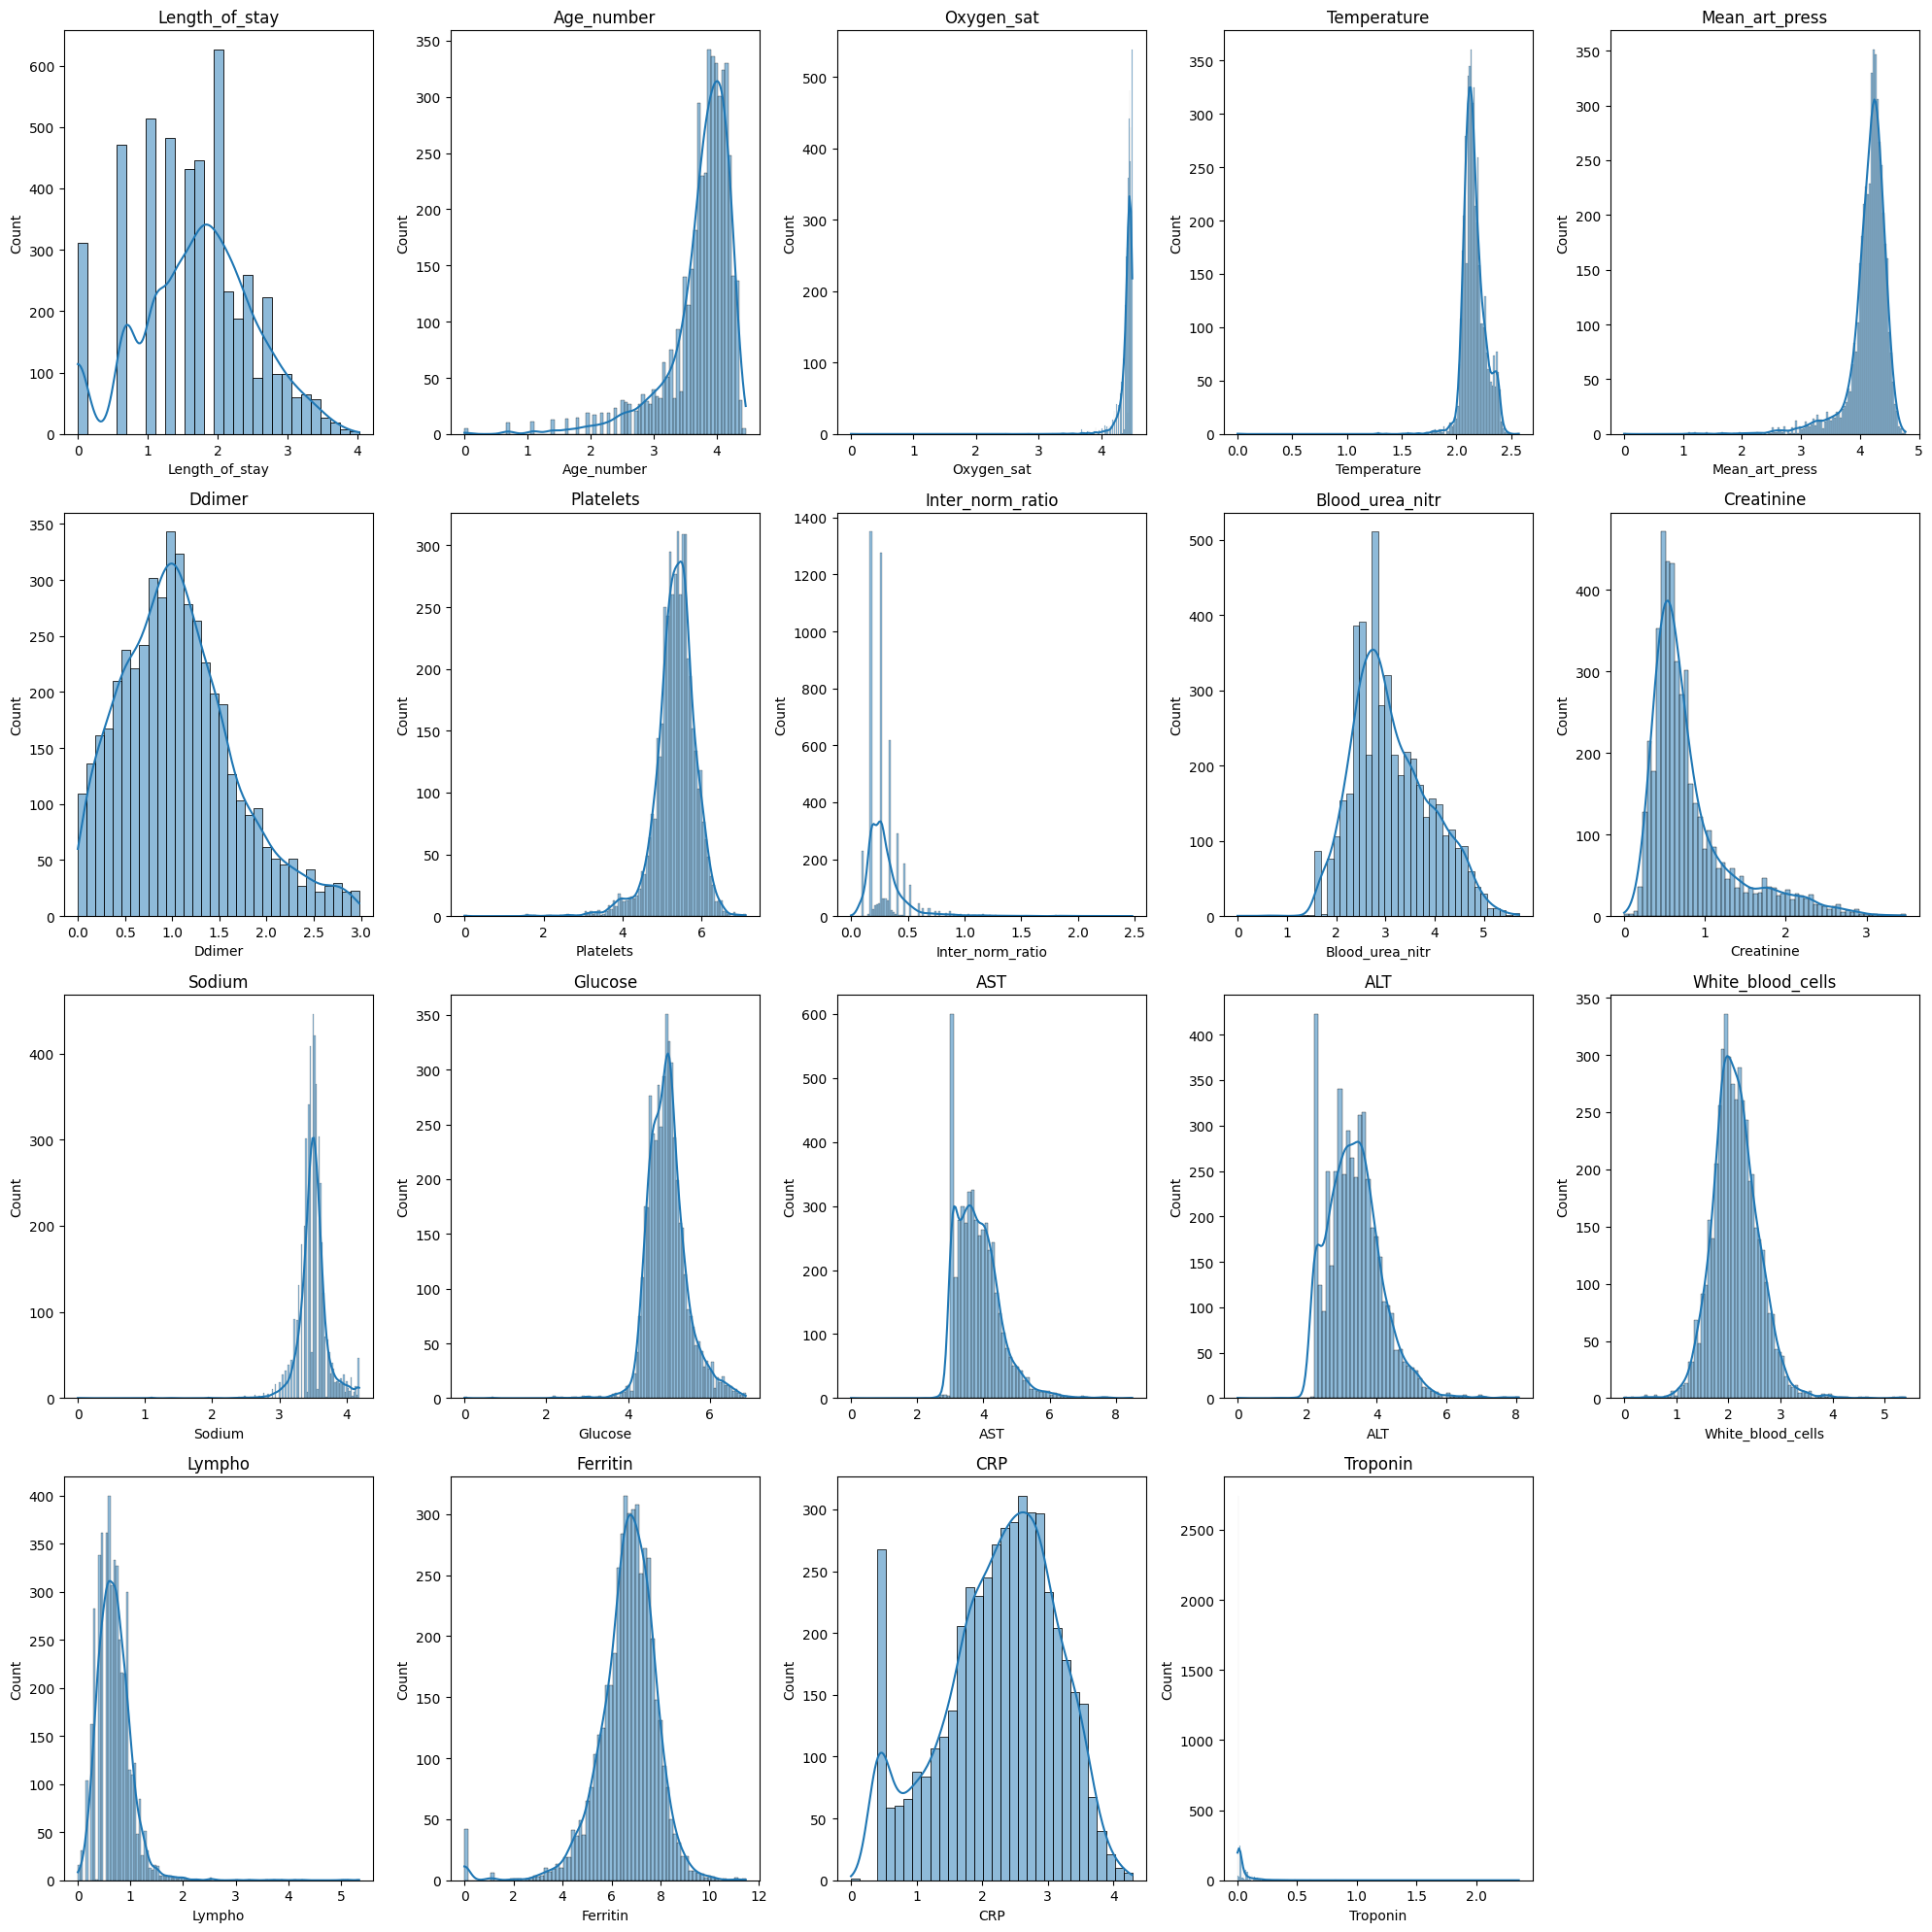

In [20]:

# Ensure all values are positive
data_copy[selectedColumns] = data_copy[selectedColumns] + 1 - data_copy[selectedColumns].min()

# Apply log transformation
data_copy[selectedColumns] = np.log(data_copy[selectedColumns])

# Set up the figure with subplots (5 plots in a row)
num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

# Flatten the axes if there is more than one row
axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data_copy[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

# Remove any empty subplots
for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## ANOVA pre vplyv numerických atr. na kategorický

## ANOVA pre vplyv numerických atr. na kategorický

ANOVA Test Results:
Feature		P-Value
Age_number		0.0
Blood_urea_nitr		0.0
Creatinine		3.207182488039526e-306
Ddimer		2.6143432962216123e-271
CRP		2.1501374451256628e-226
Ferritin		1.2901924474708926e-152
Inter_norm_ratio		7.26612579438853e-150
Mean_art_press		1.0196333963042029e-134
AST		2.2681567039887132e-114
Troponin		5.743054077563173e-76
Oxygen_sat		4.462462350617904e-59
Length_of_stay		2.0049606588887276e-55
Sodium		2.1483099066452612e-45
Lympho		4.7765860270826726e-37
Platelets		9.710410065144644e-32
White_blood_cells		3.597907854890683e-30
ALT		1.7447089874894136e-18
Glucose		1.0686179032329824e-13
Temperature		3.535561913617492e-08


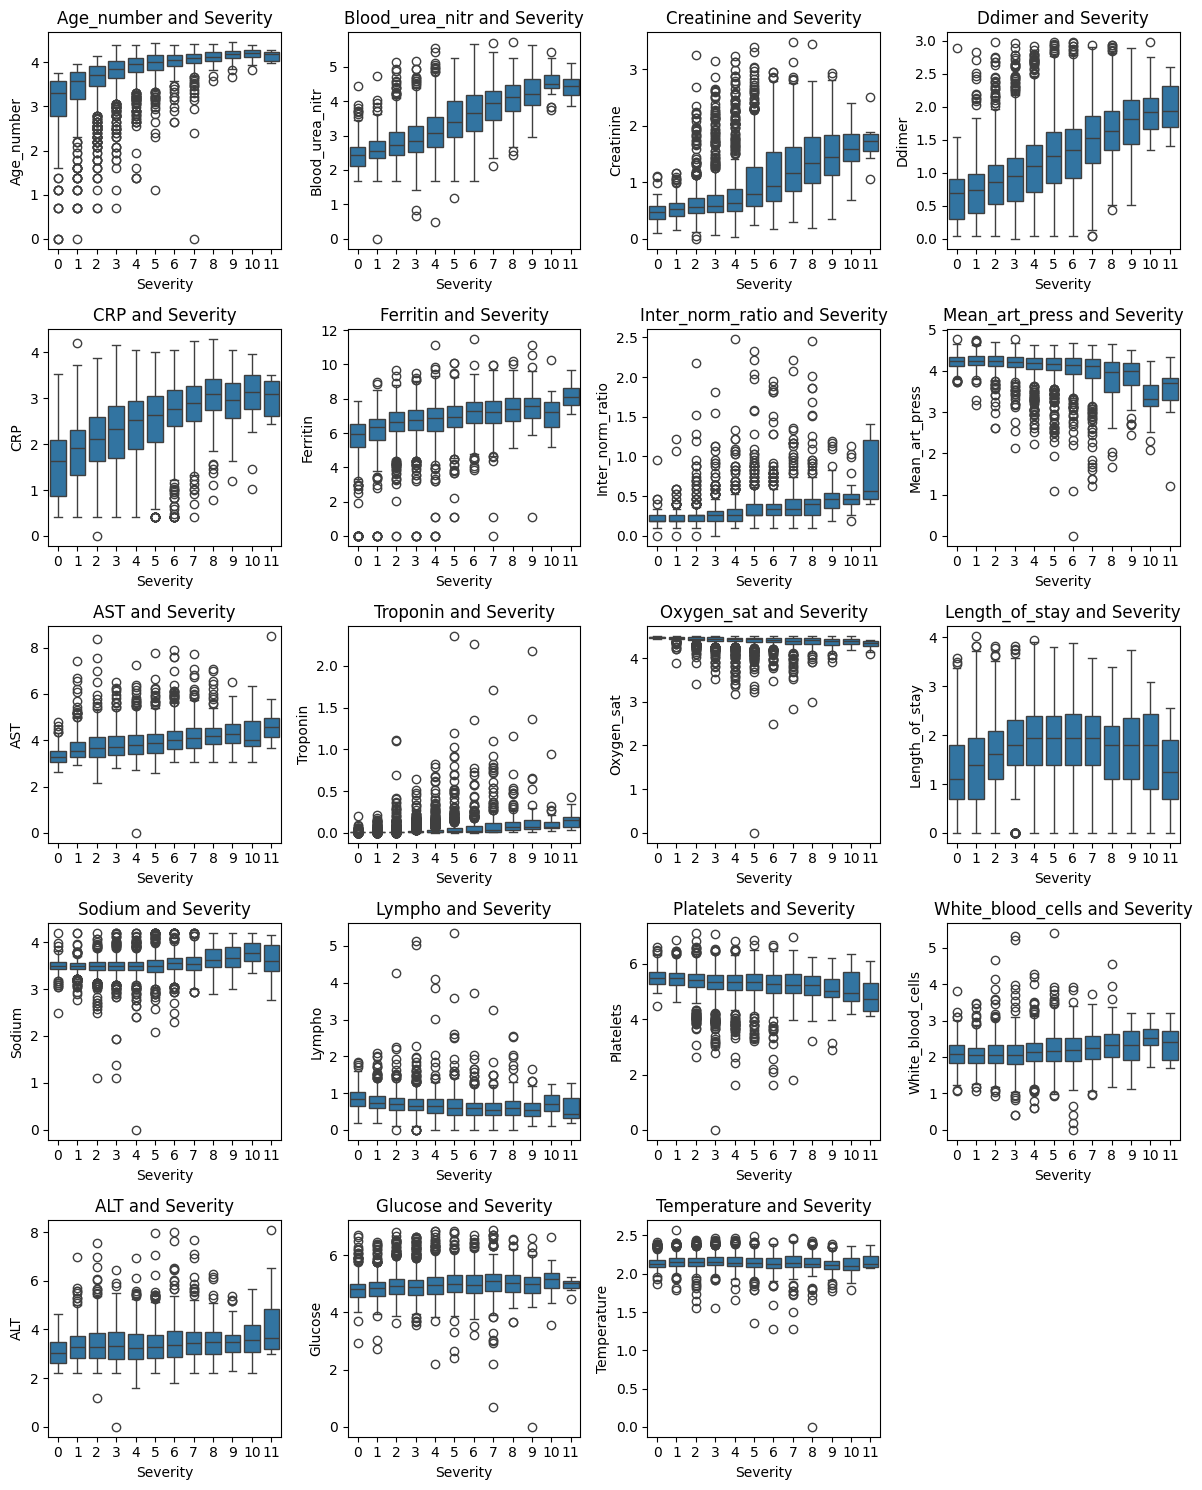

In [21]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data_copy)

# Perform ANOVA test for numeric features
f_stat, p_values_anova = f_classif(df[numeric_features], df['Severity'])

# Display p-values in ascending order
print("ANOVA Test Results:")
print("Feature\t\tP-Value")
sorted_p_values_anova = sorted(zip(numeric_features, p_values_anova), key=lambda x: x[1])
for feature, p_value_anova in sorted_p_values_anova:
    print(f"{feature}\t\t{p_value_anova}")

# Visualize boxplots for significant features
significant_features = [feature for feature, p_value in sorted_p_values_anova if p_value < 0.05]

plt.figure(figsize=(12, 15))
for i, feature in enumerate(significant_features, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x='Severity', y=feature, data=df)
    plt.title(f'{feature} and Severity')
    plt.xlabel('Severity')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()


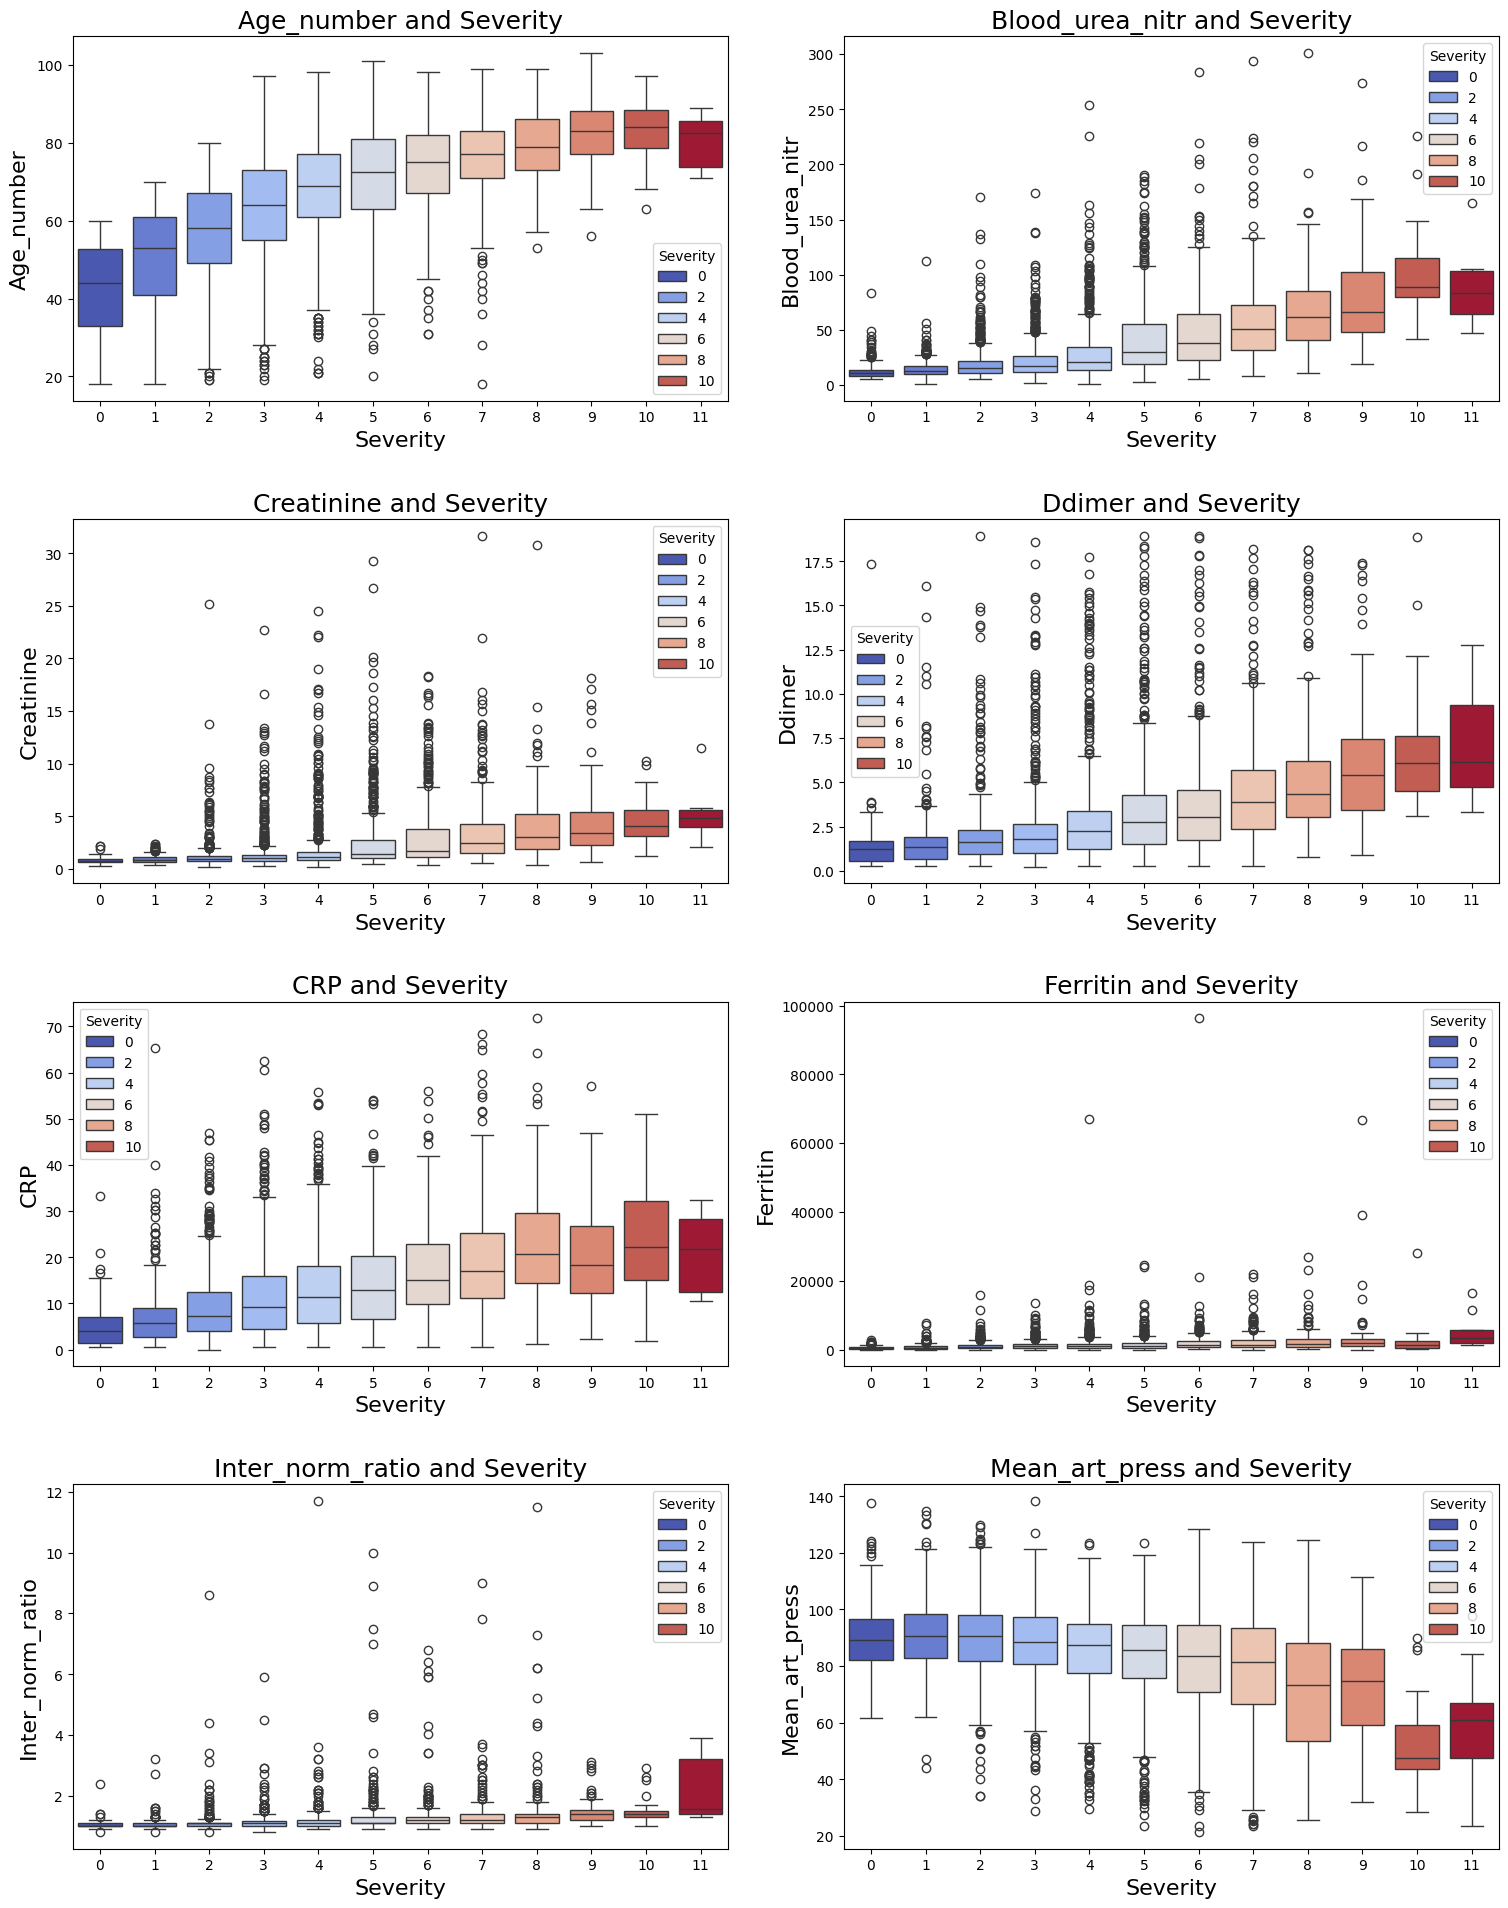

In [22]:

top_8_features = significant_features[:8]

# Setup the matplotlib figure and axes for a 4x2 subplot layout
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))

axes = axes.flatten()

# Iterate over the top 8 significant features and create boxplots
for i, feature in enumerate(top_8_features):
    sns.boxplot(x='Severity', y=feature, data=data, hue="Severity", palette="coolwarm",  ax=axes[i])
    axes[i].set_title(f'{feature} and Severity', fontsize=18)
    axes[i].set_xlabel('Severity', fontsize=16)
    axes[i].set_ylabel(feature, fontsize=16)

plt.tight_layout(pad=4.0, h_pad=3.0, w_pad=2.0)

plt.show()


ANOVA - iná

ANOVA for Age_number: F-statistic=40.4809, p-value=0.0
ANOVA for Blood_urea_nitr: F-statistic=4.8800, p-value=1.1793906294127472e-242
ANOVA for Creatinine: F-statistic=3.8698, p-value=3.743727779911011e-179
ANOVA for Troponin: F-statistic=4.2658, p-value=8.835433237498599e-164
ANOVA for Inter_norm_ratio: F-statistic=3.4125, p-value=5.805196452489095e-112
ANOVA for Oxygen_sat: F-statistic=4.0510, p-value=5.138461977404849e-75
ANOVA for CRP: F-statistic=2.0631, p-value=8.60541458082169e-62
ANOVA for Ddimer: F-statistic=1.9083, p-value=2.8101982647296133e-55
ANOVA for AST: F-statistic=2.3425, p-value=3.245849050420932e-53
ANOVA for Mean_art_press: F-statistic=2.3113, p-value=1.3857350435867767e-46
ANOVA for Sodium: F-statistic=2.6929, p-value=2.376945839001487e-42
ANOVA for Length_of_stay: F-statistic=5.1207, p-value=5.652278450420474e-28
ANOVA for Lympho: F-statistic=1.9379, p-value=3.003365924906849e-16
ANOVA for Platelets: F-statistic=1.4429, p-value=8.418612520113626e-12
ANOVA for Fer

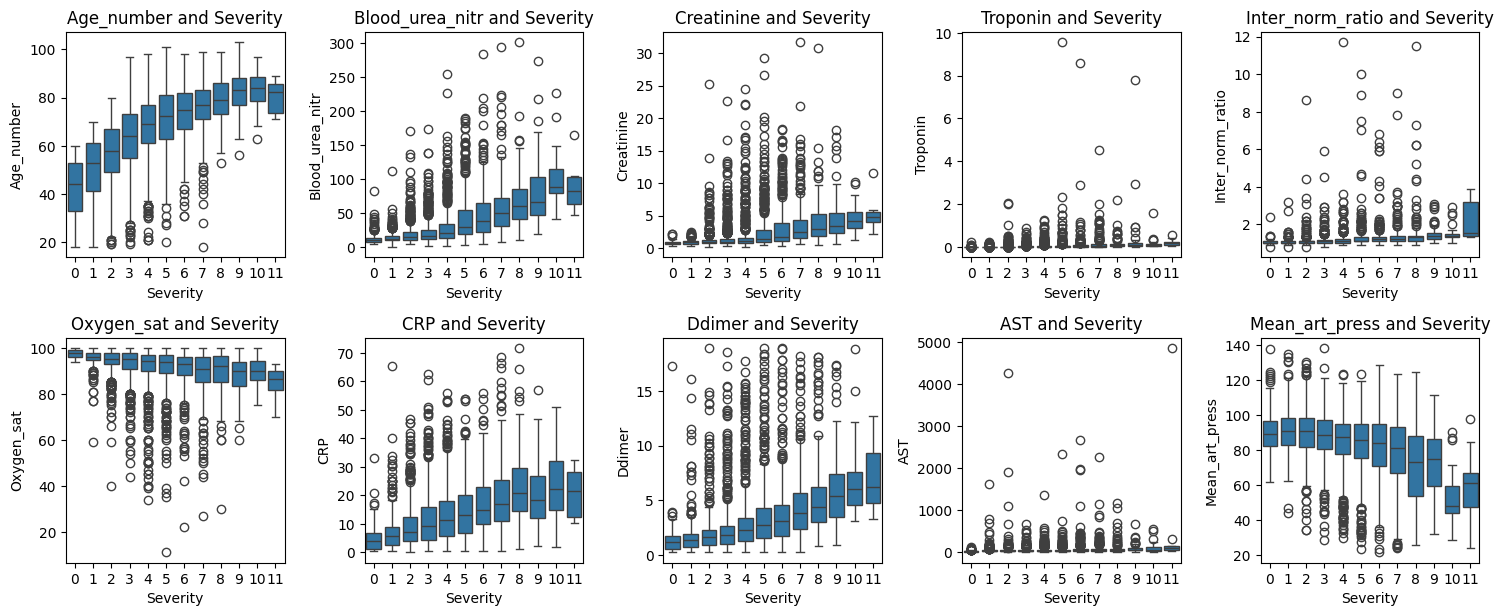

In [23]:
from scipy.stats import f_oneway

# Perform ANOVA for each categorical feature
anova_results = {}
for num_feature in numeric_features:
    groups = [data[data[num_feature] == numeric]['Severity'] for numeric in data[num_feature].unique()]
    anova_result = f_oneway(*groups)
    anova_results[num_feature] = anova_result


# Sort the ANOVA results by p-values
sorted_results = sorted(anova_results.items(), key=lambda x: x[1].pvalue)

# Display ANOVA results for the top 10 categorical features
for num_feature, result in sorted_results[:15]:
    print(f"ANOVA for {num_feature}: F-statistic={result.statistic:.4f}, p-value={result.pvalue}")


# Plot box plots for the top 10 categorical features
plt.figure(figsize=(15, 15))
for i, (num_feature, _) in enumerate(sorted_results[:10], 1):
    plt.subplot(5, 5, i)
    sns.boxplot(x="Severity", y=num_feature, data=data)
    plt.title(f'{num_feature} and Severity')

plt.tight_layout()
plt.show()

Korelačná matica

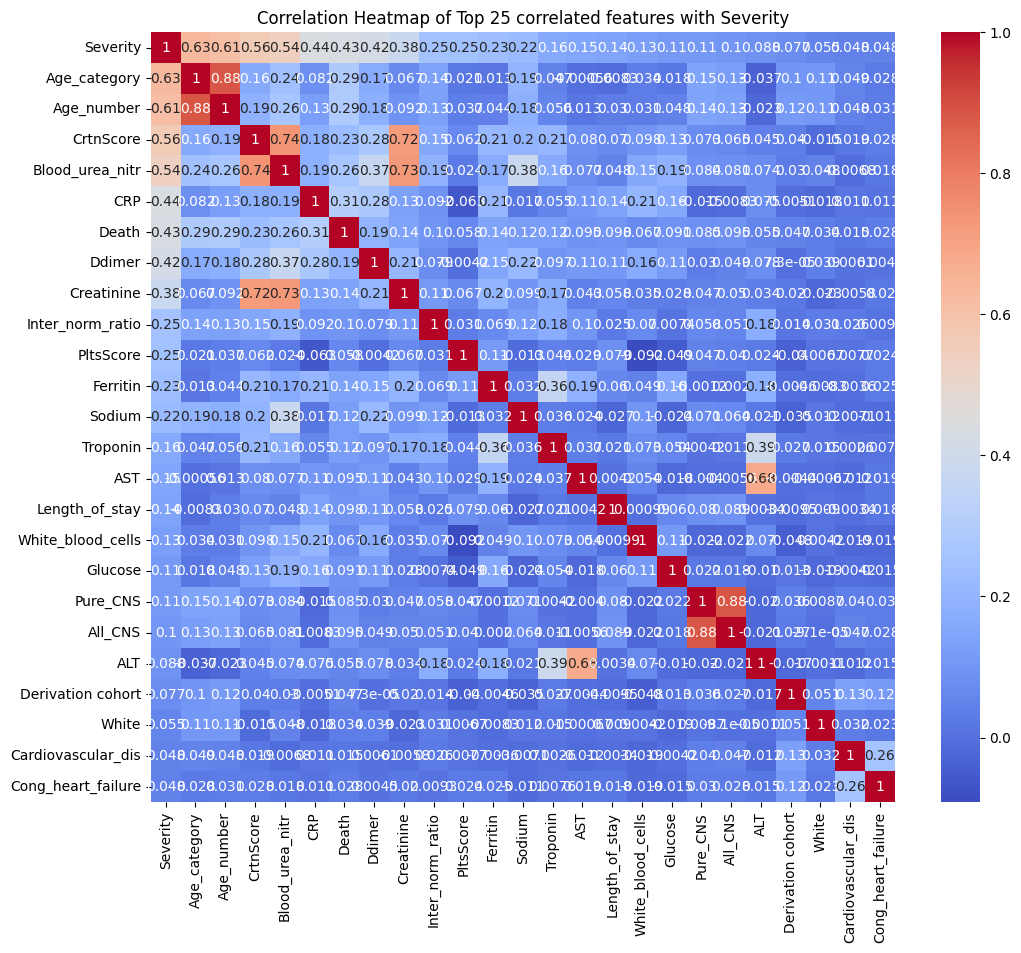

In [24]:
# Calculate the correlation between variables and Severity_class
correlation_with_Severity = data.corr()[['Severity']].sort_values(by=['Severity'], ascending=False)

# Extract the top 25
top_25_features = correlation_with_Severity[:25].index

# Get the correlation matrix for the top 25 features
correlation_matrix = data[top_25_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Top 25 correlated features with Severity')
plt.show()



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



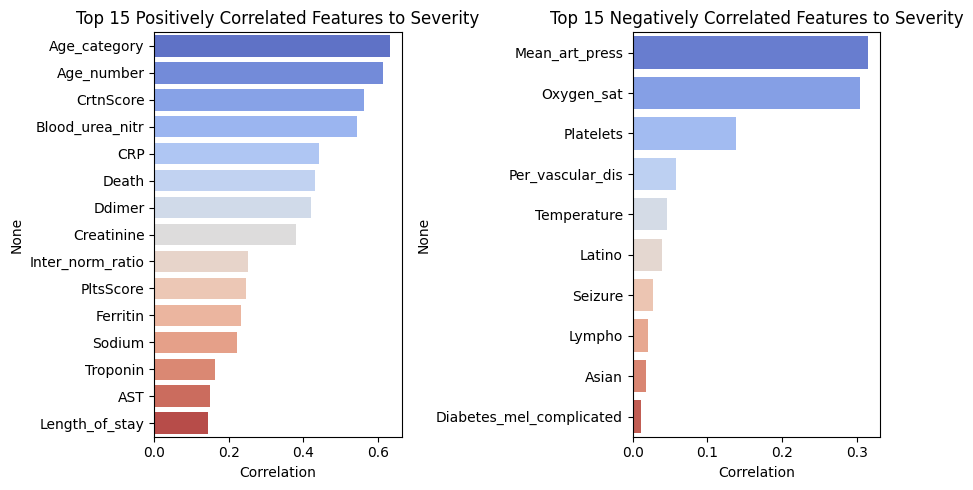

In [25]:
# Calculate the correlations between all features and 'Severity'
correlations = data.corr()['Severity'].drop('Severity')

# Split correlations into positive and negative
positive_correlations = correlations[correlations > 0]
negative_correlations = correlations[correlations < 0]

# Sort the correlations by their absolute values in descending order
positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 15

# Plot the most positively correlated features
plt.figure(figsize=(9, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.title(f'Top {n_top_features} Positively Correlated Features to Severity')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette="coolwarm")
plt.xlabel('Correlation')
plt.title(f'Top {n_top_features} Negatively Correlated Features to Severity')

plt.tight_layout()
plt.show()

# Normalizácia pôvodných dát pre modelovanie

### Výber numerických atribútov

In [26]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['Severity', 'CrtnScore','PltsScore','Age_category', "Per_vascular_dis"]) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Age_number', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin', 'CRP', 'Troponin']
19


Numeric features distributions

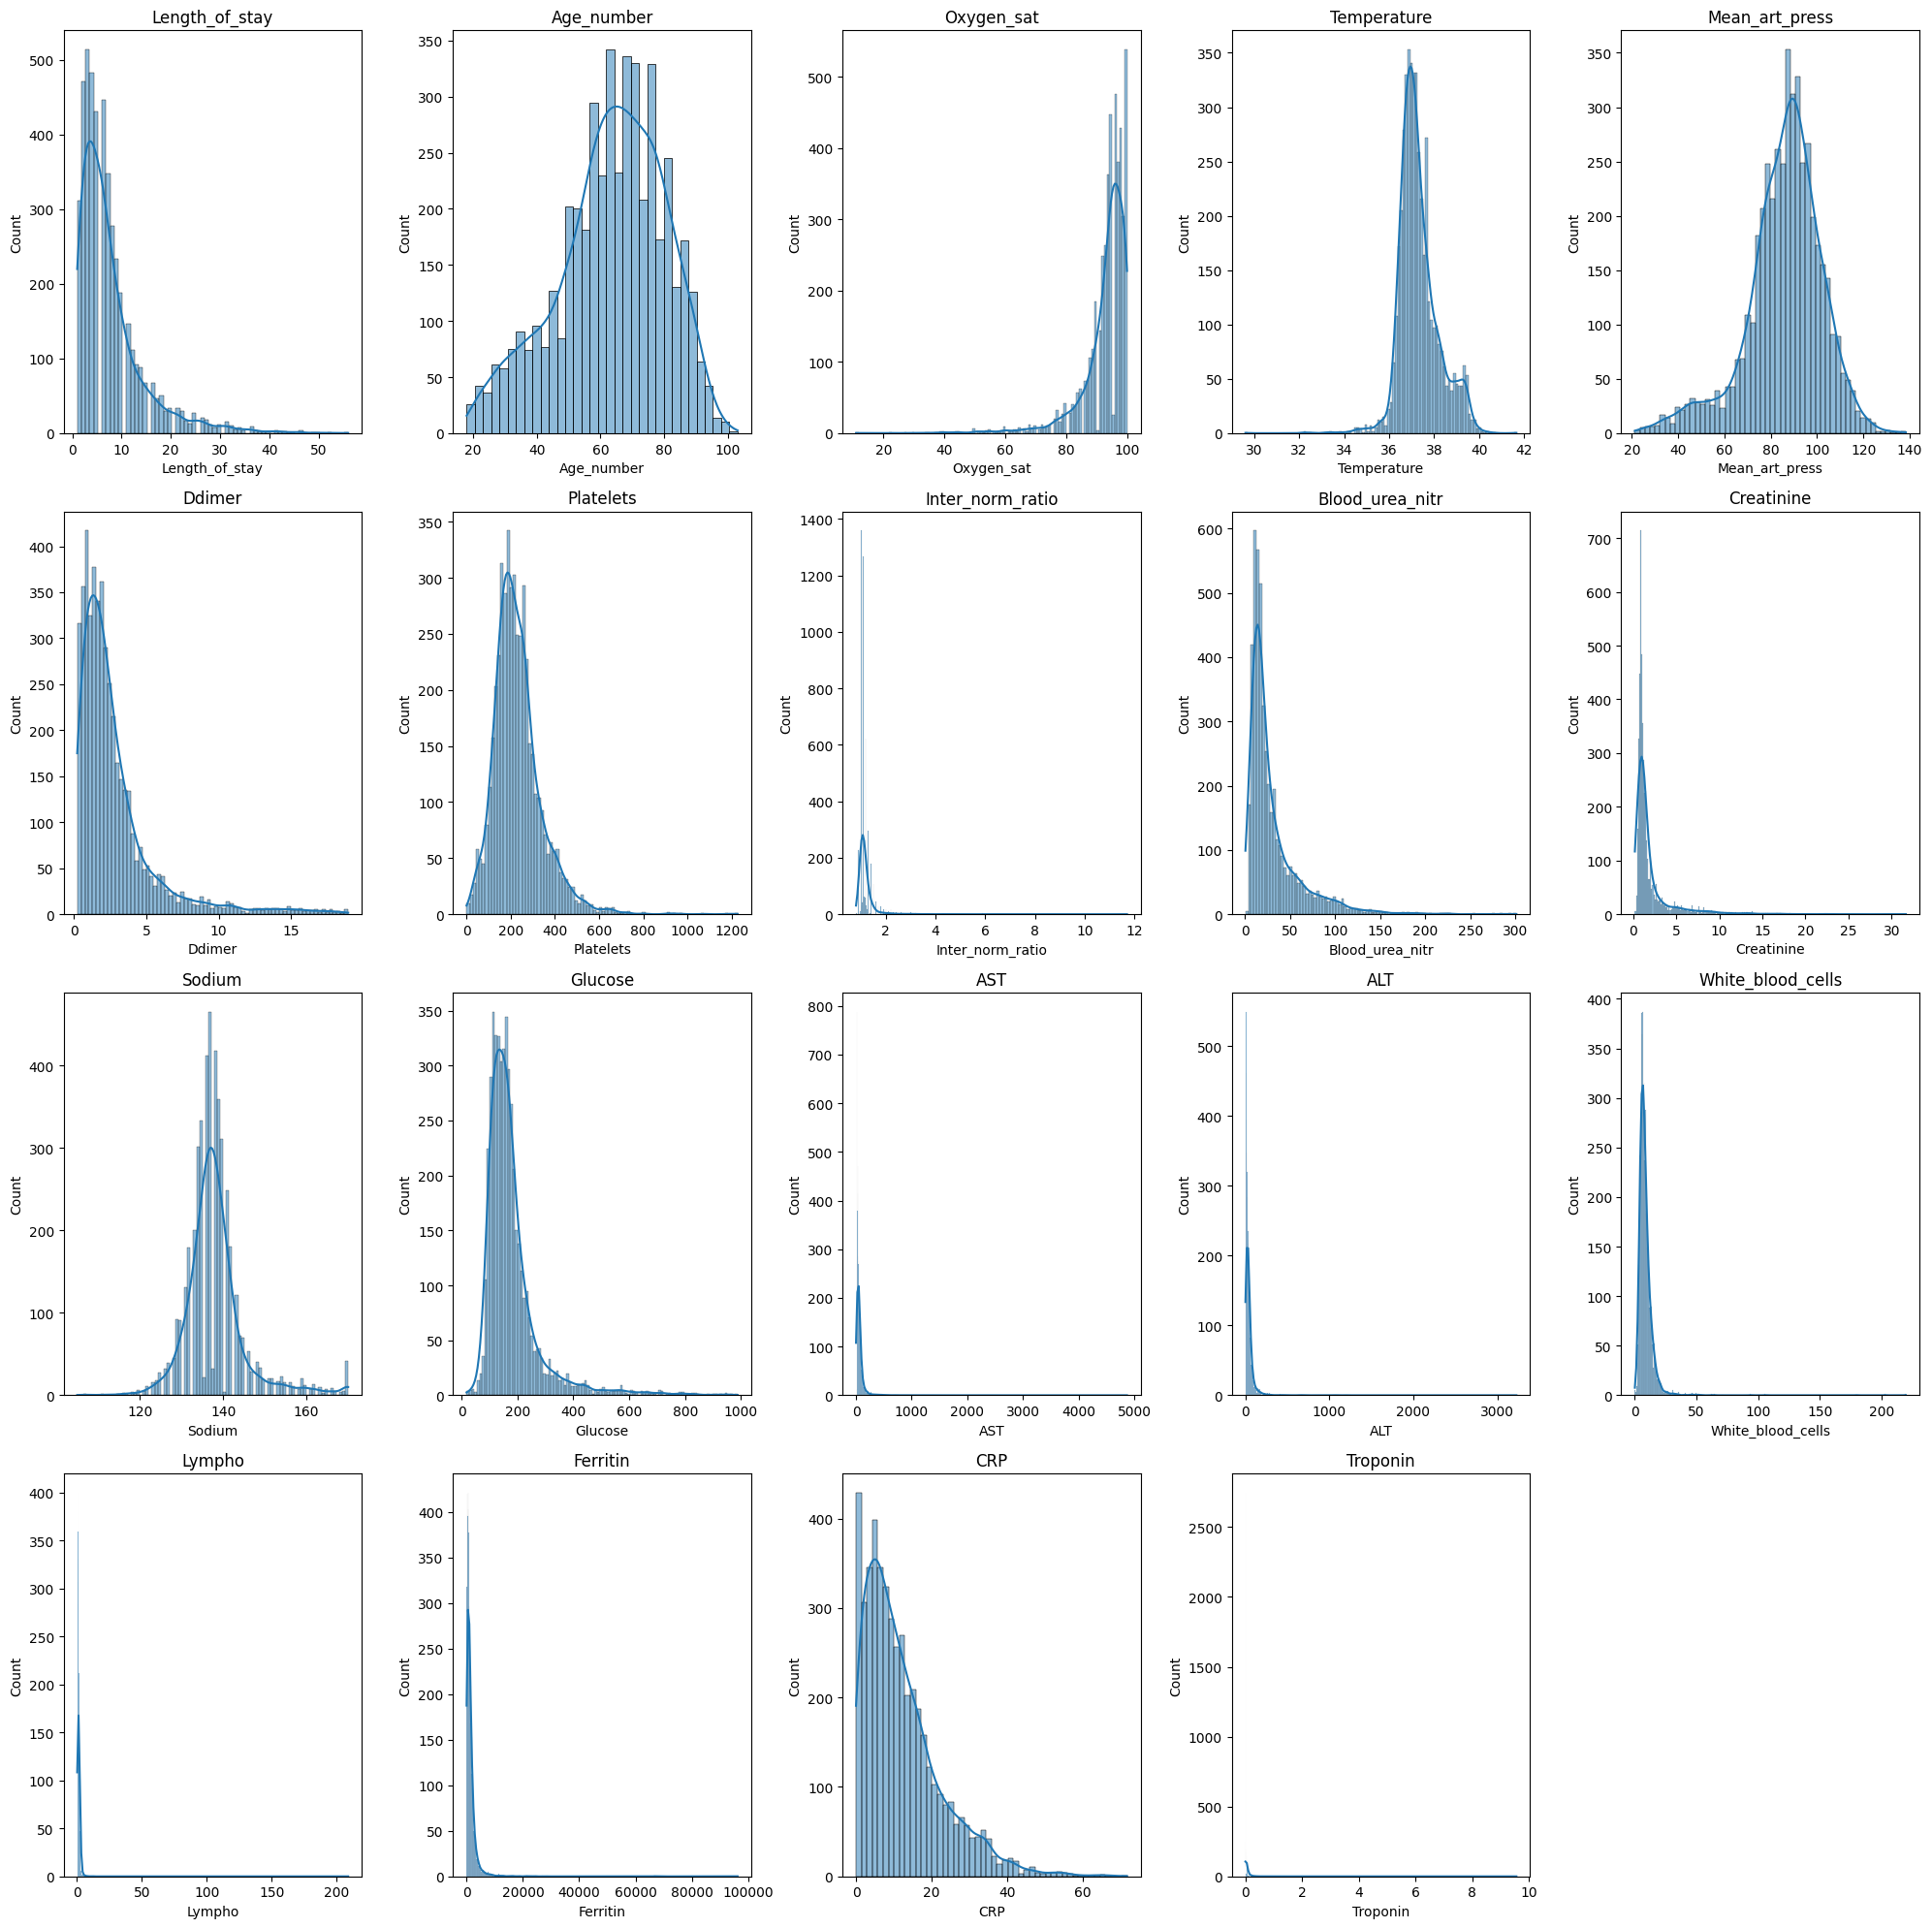

In [27]:
num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

MinMax normalizácia numerických atribútov

In [28]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# Select the columns we want to normalize
columns_to_normalize = selectedColumns

# Create a new DataFrame for the columns to normalize
data_to_normalize = data[columns_to_normalize]

# Normalize using Min-Max scaling
min_max_scaler = MinMaxScaler()
data_to_normalize_minmax = min_max_scaler.fit_transform(data_to_normalize)

# Update the original DataFrame with the normalized values
data[columns_to_normalize] = data_to_normalize_minmax

data.head(5)

,Derivation cohort,Length_of_stay,Death,Black,White,Asian,Latino,Myocardial_infarction,Per_vascular_dis,Cong_heart_failure,...,Sodium,Glucose,AST,ALT,White_blood_cells,Lympho,Ferritin,CRP,Troponin,Severity
0,1,0.000000,0,0,0,0,0,0,0,0,...,0.461531,0.096907,0.005338,0.003723,0.024601,0.006220,0.000000,0.006966,0.001046,3
1,1,0.018182,1,0,1,0,0,0,1,0,...,0.492300,0.254639,0.017450,0.009303,0.054670,0.000957,0.009192,0.207625,0.125523,7
2,1,0.018182,1,0,1,0,0,0,1,1,...,0.538453,0.106186,0.006569,0.004963,0.026879,0.001914,0.006533,0.472382,0.004156,7
3,1,0.254545,0,1,0,0,0,1,0,0,...,0.415378,0.170876,0.009033,0.004653,0.015945,0.001914,0.008475,0.256396,0.005230,9
4,1,0.145455,0,1,0,0,0,0,0,0,...,0.676913,0.170042,0.007801,0.008063,0.025057,0.006220,0.017563,0.161641,0.001046,7


Vytvorenie pomocných "dummies" atribútov pre kategorické atribúty

In [29]:
# Use pandas get_dummies to create dummy variables for each categorical column
data = pd.get_dummies(data, columns=['CrtnScore', 'PltsScore', 'Age_category','Per_vascular_dis'], prefix=['CrtnScore', 'PltsScore', 'Age_category', 'Per_vascular_dis'])

data.head(5)

,Derivation cohort,Length_of_stay,Death,Black,White,Asian,Latino,Myocardial_infarction,Cong_heart_failure,Cardiovascular_dis,...,PltsScore_0,PltsScore_1,PltsScore_2,Age_category_0,Age_category_1,Age_category_2,Age_category_3,Per_vascular_dis_0,Per_vascular_dis_1,Per_vascular_dis_2
0,1,0.000000,0,0,0,0,0,0,0,0,...,True,False,False,False,False,False,True,True,False,False
1,1,0.018182,1,0,1,0,0,0,0,0,...,True,False,False,False,True,False,False,False,True,False
2,1,0.018182,1,0,1,0,0,0,1,1,...,False,True,False,False,False,False,True,False,True,False
3,1,0.254545,0,1,0,0,0,1,0,0,...,True,False,False,False,False,True,False,True,False,False
4,1,0.145455,0,1,0,0,0,0,0,0,...,False,True,False,False,False,True,False,True,False,False


In [30]:
data.columns


Index(['Derivation cohort', 'Length_of_stay', 'Death', 'Black', 'White',
       'Asian', 'Latino', 'Myocardial_infarction', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_number', 'Oxygen_sat',
       'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets',
       'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium',
       'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin',
       'CRP', 'Troponin', 'Severity', 'CrtnScore_0', 'CrtnScore_1',
       'CrtnScore_2', 'PltsScore_0', 'PltsScore_1', 'PltsScore_2',
       'Age_category_0', 'Age_category_1', 'Age_category_2', 'Age_category_3',
       'Per_vascular_dis_0', 'Per_vascular_dis_1', 'Per_vascular_dis_2'],
      dtype='object')

In [31]:
data.columns.size

54

In [ ]:
pip install --upgrade scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 53.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2


# PREDICTING SEVERITY


## Atribút Severity_class

In [32]:
data["Severity"].unique() # 12 different values

array([ 3,  7,  9,  5,  2,  6,  4,  0,  1, 10,  8, 11])

A) Prvý typ rozdelenia

In [33]:
# Define bin edges
bins = [0, 3, 6, 12]
# Define labels for each bin
labels = [0,1,2]

# Create a new column with bins
data['Severity_class'] = pd.cut(data['Severity'], bins=bins, labels=labels, right=False)

Text(0.5, 1.0, 'Severity class')

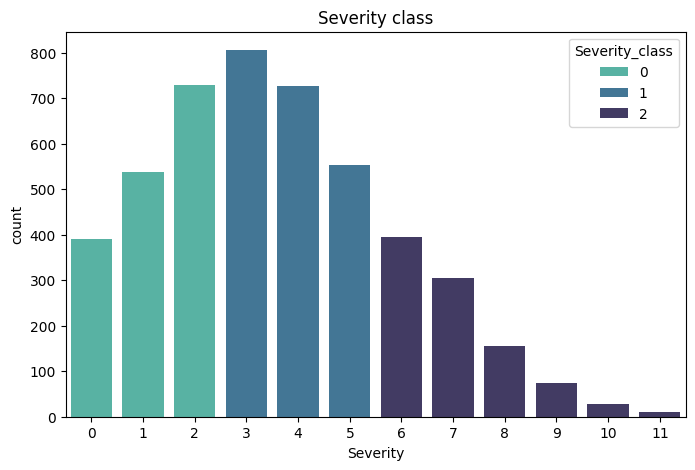

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Severity", hue="Severity_class",data=data, palette="mako_r")
plt.title("Severity class")

A) Prvý typ rozdelenia závažnosti priebehu QCUT - vyššia presnosť

In [ ]:
labels = [0, 1,2]
data['Severity_class'] = pd.qcut(x=data["Severity"], q=3, labels=labels, retbins=False)

In [ ]:
data['Severity_class'] =pd.to_numeric(data['Severity_class'])

<Axes: xlabel='Severity', ylabel='count'>

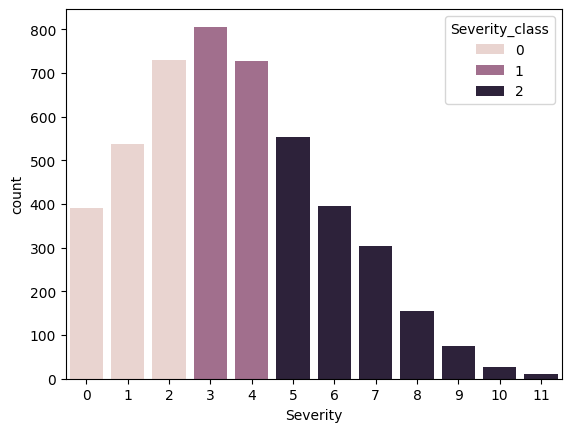

In [ ]:
sns.countplot(x="Severity", hue="Severity_class",data=data)

Text(0.5, 1.0, 'Severity class counts')

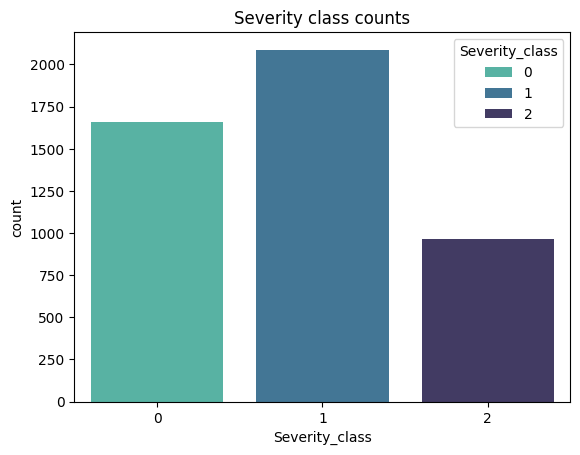

In [ ]:

sns.countplot(x= "Severity_class", data=data, hue="Severity_class", palette="mako_r")
plt.title("Severity class counts")

# PREDICTING SEVERITY CLASS WITH ALL FEATURES
##  = MULTICLASS CLASSIFICATION

In [61]:
X = data.drop(columns=["Death","Severity","Severity_class"])
y = data["Severity_class"]

In [62]:
X.columns

Index(['Derivation cohort', 'Length_of_stay', 'Black', 'White', 'Asian',
       'Latino', 'Myocardial_infarction', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_number', 'Oxygen_sat',
       'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets',
       'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium',
       'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin',
       'CRP', 'Troponin', 'CrtnScore_0', 'CrtnScore_1', 'CrtnScore_2',
       'PltsScore_0', 'PltsScore_1', 'PltsScore_2', 'Age_category_0',
       'Age_category_1', 'Age_category_2', 'Age_category_3',
       'Per_vascular_dis_0', 'Per_vascular_dis_1', 'Per_vascular_dis_2'],
      dtype='object')

In [63]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4711 entries, 0 to 4710
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Derivation cohort         4711 non-null   int64  
 1   Length_of_stay            4711 non-null   float64
 2   Black                     4711 non-null   int64  
 3   White                     4711 non-null   int64  
 4   Asian                     4711 non-null   int64  
 5   Latino                    4711 non-null   int64  
 6   Myocardial_infarction     4711 non-null   int64  
 7   Cong_heart_failure        4711 non-null   int64  
 8   Cardiovascular_dis        4711 non-null   int64  
 9   Dementia                  4711 non-null   int64  
 10  Chronic_obst_pulm_dis     4711 non-null   int64  
 11  Diabetes_mel_complicated  4711 non-null   int64  
 12  Diabetes_mel_simple       4711 non-null   int64  
 13  Renal_dis                 4711 non-null   int64  
 14  All_CNS 

In [64]:
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (3768, 52)
Test_x : (943, 52)
Train_y : (3768,)
Test_y : (943,)


# Základné modely, 5- násobná krížová validácia na trénovacej množine

In [39]:
# Define models to test for a 3-class classification problem
models = [
    ('RandomForest', RandomForestClassifier(n_estimators=100)),
    ('LGBM', LGBMClassifier()),
    ('XGB', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ('KNN', KNeighborsClassifier()),
    ('NaiveBayes', GaussianNB()),
    ('SVC', SVC(probability=True)),
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
    ('MLP', MLPClassifier()),
]


accuracy_scores = []
for name, model in models:
    # Use accuracy as the scoring metric for cross-validation
    cv_accuracy = np.mean(cross_val_score(model, train_x, train_y, cv=5, scoring='accuracy'))
    accuracy_scores.append((name, cv_accuracy))
    print(f"{name}: Mean cross-validation accuracy = {cv_accuracy:.4f}")

# Identify the model with the best accuracy score
best_model_accuracy = max(accuracy_scores, key=lambda x: x[1])
print(f"\nBest model based on accuracy is {best_model_accuracy[0]} with a score of {best_model_accuracy[1]:.4f}")


RandomForest: Mean cross-validation accuracy = 0.8639
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3773
[LightGBM] [Info] Number of data points in the train set: 3014, number of used features: 51
[LightGBM] [Info] Start training from score -1.048780
[LightGBM] [Info] Start training from score -0.801683
[LightGBM] [Info] Start training from score -1.604143
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3748
[LightGBM] [

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.


MLP: Mean cross-validation accuracy = 0.7930

Best model based on accuracy is LGBM with a score of 0.8933


Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.


# Logistic Regression

In [40]:
logreg = LogisticRegression(class_weight= "balanced")
logreg.fit(train_x,train_y)

pred = logreg.predict(test_x)
print(classification_report(pred, test_y))

# Print accuracy on the test set
print("Logistic Regression Accuracy on Test set:", accuracy_score(pred, test_y))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84       359
           1       0.65      0.77      0.71       338
           2       0.83      0.71      0.76       246

    accuracy                           0.77       943
   macro avg       0.79      0.76      0.77       943
weighted avg       0.78      0.77      0.77       943

Logistic Regression Accuracy on Test set: 0.7709437963944857


lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


# MLP

In [41]:
nn_model = MLPClassifier(max_iter=1000)

# Train the neural network model
nn_model.fit(train_x, train_y)

# Make predictions on the test set
predictions = nn_model.predict(test_x)

# Generate and print the classification report
print(classification_report(test_y, predictions))

accuracy = accuracy_score(test_y, predictions)
print("Multilayer Perceptron Neural Network Accuracy:", accuracy)


              precision    recall  f1-score   support

           0       0.83      0.86      0.85       336
           1       0.75      0.76      0.75       398
           2       0.80      0.75      0.78       209

    accuracy                           0.79       943
   macro avg       0.80      0.79      0.79       943
weighted avg       0.79      0.79      0.79       943

Multilayer Perceptron Neural Network Accuracy: 0.792152704135737


# Random Forest

In [43]:
# Creating the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fitting the model with the training data
rf.fit(train_x, train_y)

# Predicting the Test set results
y_pred = rf.predict(test_x)

# Evaluating the model
accuracy = accuracy_score(test_y, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

print(classification_report(y_pred, test_y))
print("Random Forest Accuracy on Test set:", rf.score(test_x, test_y))

Accuracy: 85.47%
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       321
           1       0.88      0.80      0.84       439
           2       0.76      0.87      0.81       183

    accuracy                           0.85       943
   macro avg       0.84      0.86      0.85       943
weighted avg       0.86      0.85      0.85       943

Random Forest Accuracy on Test set: 0.8547189819724285


# XGBoost

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       334
           1       0.88      0.85      0.87       412
           2       0.81      0.86      0.84       197

    accuracy                           0.89       943
   macro avg       0.88      0.89      0.88       943
weighted avg       0.89      0.89      0.89       943

XGBoost Accuracy: 0.887592788971368


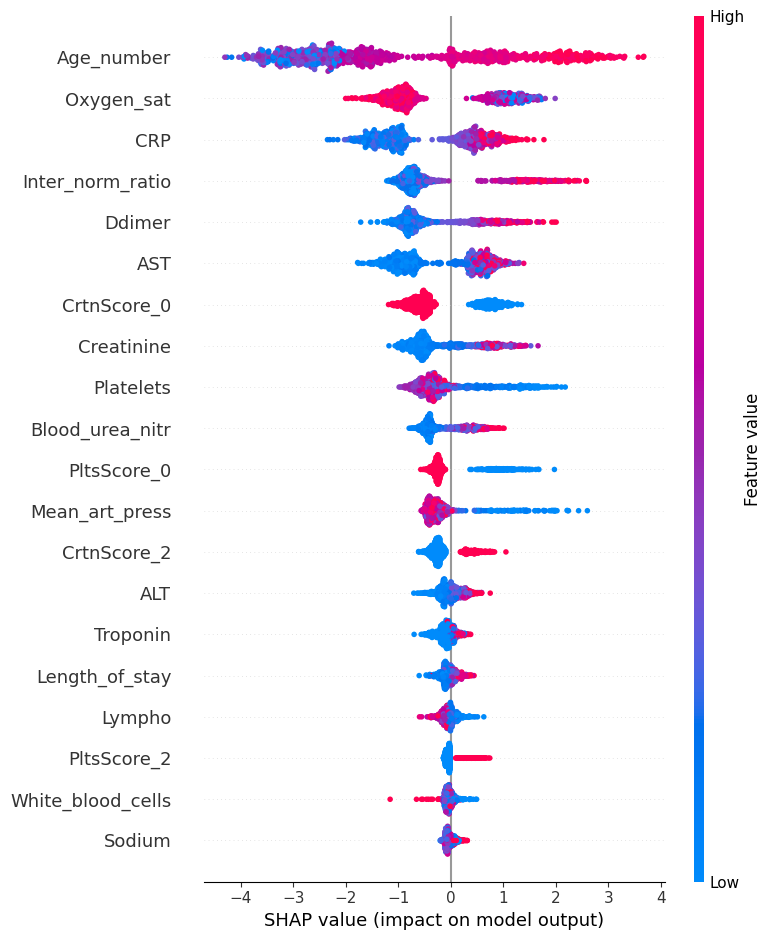

In [65]:

xgb_model = xgb.XGBClassifier()
xgb_model.fit(train_x, train_y)

# Make predictions on the test set
predictions = xgb_model.predict(test_x)

print(classification_report(predictions, test_y))
accuracy = accuracy_score(test_y, predictions)
print("XGBoost Accuracy:", accuracy)

# Create object that can calculate shap values
explainer = shap.TreeExplainer(xgb_model)


shap_values = explainer.shap_values(test_x)

# Make plot for class 2
shap.summary_plot(shap_values[2], test_x)

# LightGBM - základné parametre

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001971 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3860
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 52
[LightGBM] [Info] Start training from score -1.048913
[LightGBM] [Info] Start training from score -0.801816
[LightGBM] [Info] Start training from score -1.603616
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       338
           1       0.88      0.85      0.87       411
           2       0.81      0.87      0.84       194

    accuracy                           0.88       943
   macro avg       0.88      0.88      0.88       943
weighted avg       0.89      0.88      0.88       943

Accuracy on Test set: 0.8

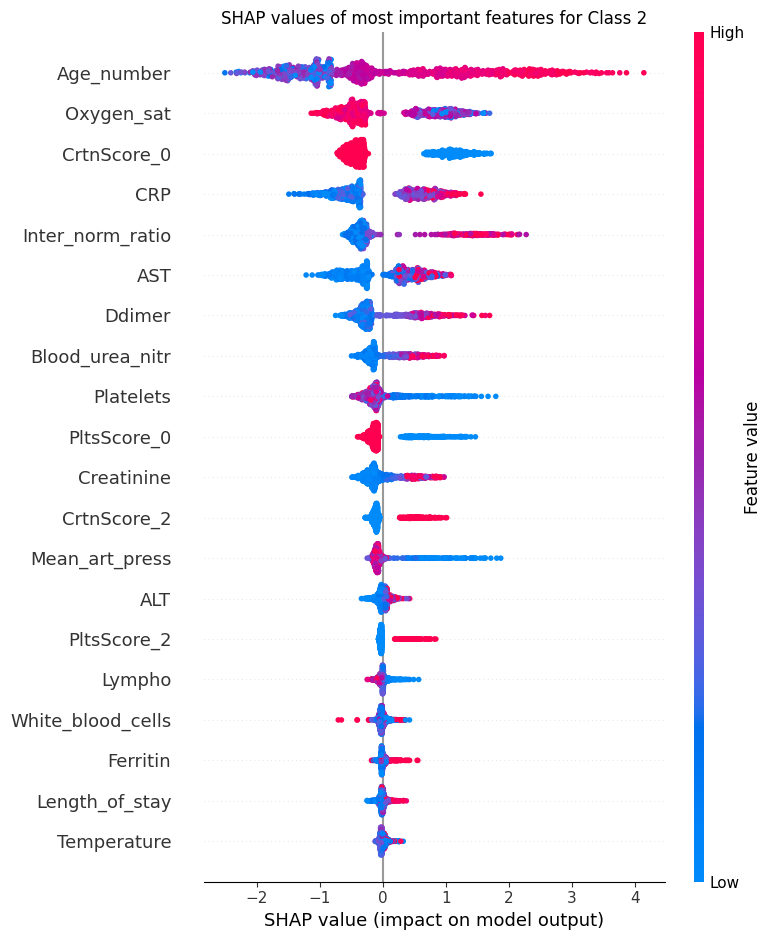

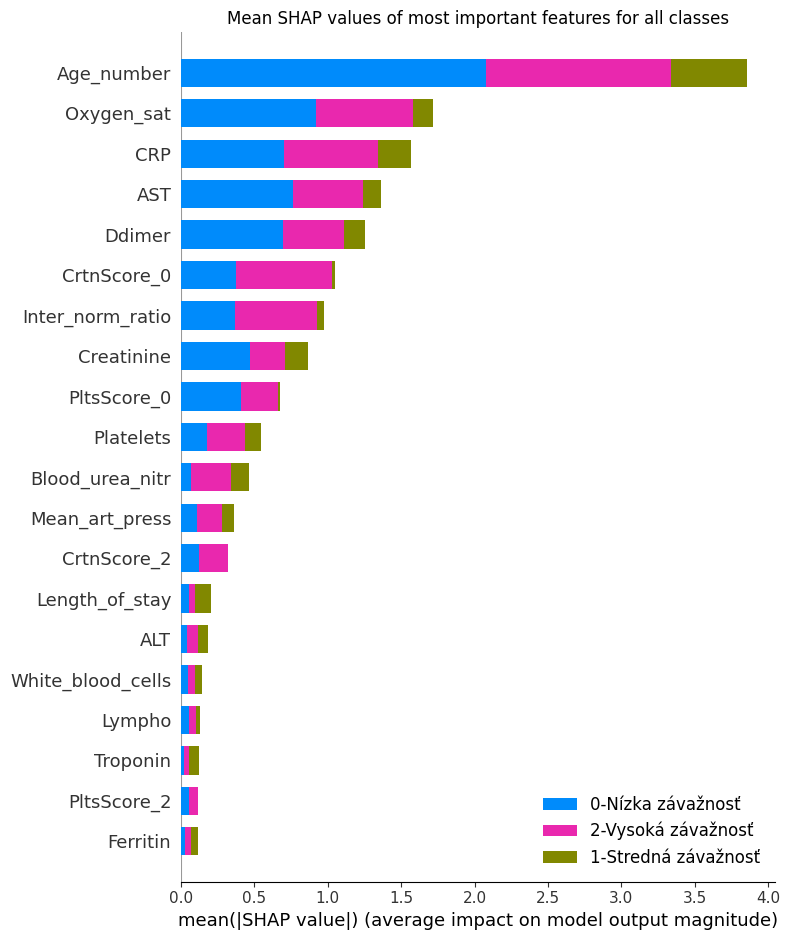

In [66]:
lgb = LGBMClassifier(objective='multiclass', num_class=3)
lgb.fit(train_x, train_y)
pred = lgb.predict(test_x)

y_prob = lgb.predict_proba(test_x)

print(classification_report(pred, test_y))
accuracy = accuracy_score(test_y, pred)
print(f"Accuracy on Test set: {accuracy}")

explainer = shap.TreeExplainer(lgb)

# calculate shap values
shap_values = explainer.shap_values(test_x)

plt.title("SHAP values of most important features for Class 2")
shap.summary_plot(shap_values[2], test_x)

plt.title("Mean SHAP values of most important features for all classes")
shap.summary_plot(shap_values, test_x, class_names=["0-Nízka závažnosť", "1-Stredná závažnosť", "2-Vysoká závažnosť"])

# Select top 10 features for LightGBM
Aggregate SHAP values for all 3 classes and select top features


In [45]:
# Calculate the mean absolute SHAP value for each feature across all classes
shap_values_aggregated = np.abs(shap_values).mean(axis=0)

if isinstance(shap_values, list):
    shap_values_aggregated = np.concatenate([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)

# Get feature names from the dataset
feature_names = test_x.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean SHAP Value': shap_values_aggregated
}).sort_values(by='Mean SHAP Value', ascending=False)

# Extract the top 10 features
top_10_features_df = feature_importance_df.head(10)
top_10_features_list = top_10_features_df['Feature'].tolist()

print("Top 10 Features DataFrame:\n", top_10_features_df)
print("\nTop 10 Features List:\n", top_10_features_list)

X = data[top_10_features_list]
y = data["Severity_class"]

Top 10 Features DataFrame:
              Feature  Mean SHAP Value
21        Age_number         1.284734
22        Oxygen_sat         0.571215
37               CRP         0.521786
32               AST         0.454422
25            Ddimer         0.416724
39       CrtnScore_0         0.350076
27  Inter_norm_ratio         0.324432
29        Creatinine         0.289122
42       PltsScore_0         0.225043
26         Platelets         0.180822

Top 10 Features List:
 ['Age_number', 'Oxygen_sat', 'CRP', 'AST', 'Ddimer', 'CrtnScore_0', 'Inter_norm_ratio', 'Creatinine', 'PltsScore_0', 'Platelets']


Remove Score features

In [67]:
top_features_list = ['Age_number', 'Oxygen_sat', 'CRP', 'AST', 'Ddimer',  'Inter_norm_ratio', 'Creatinine', 'Platelets']

## Create new model trained on top 8 features

In [68]:
X = data[top_features_list]
y = data["Severity_class"]

In [69]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4711 entries, 0 to 4710
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age_number        4711 non-null   float64
 1   Oxygen_sat        4711 non-null   float64
 2   CRP               4711 non-null   float64
 3   AST               4711 non-null   float64
 4   Ddimer            4711 non-null   float64
 5   Inter_norm_ratio  4711 non-null   float64
 6   Creatinine        4711 non-null   float64
 7   Platelets         4711 non-null   float64
dtypes: float64(8)
memory usage: 294.6 KB


In [49]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (3768, 8)
Test_x : (943, 8)
Train_y : (3768,)
Test_y : (943,)


## LightGBM with top 8 features

In [50]:
lgb = LGBMClassifier()
lgb.fit(train_x, train_y)
pred = lgb.predict(test_x)

y_prob = lgb.predict_proba(test_x)

print(classification_report(pred, test_y))
accuracy = accuracy_score(test_y, pred)
print(f"Accuracy on Test set: {accuracy}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1684
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 8
[LightGBM] [Info] Start training from score -1.048913
[LightGBM] [Info] Start training from score -0.801816
[LightGBM] [Info] Start training from score -1.603616
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       337
           1       0.87      0.86      0.87       404
           2       0.83      0.86      0.84       202

    accuracy                           0.89       943
   macro avg       0.88      0.88      0.88       943
weighted avg       0.89      0.89      0.89       943

Accuracy on Test set: 0.8865323435843054


## Ladenie hyperparametrov

In [ ]:
X_train_val, test_x, y_train_val, test_y = train_test_split(X, y, test_size=0.2, random_state=42)


# This results in  70% train, 20% test, and 10% val
train_x, val_x, train_y, val_y = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42)


print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)
print("val_x :",val_x.shape)
print("val_y :",val_y.shape)

In [53]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

lgb = LGBMClassifier()

# Define the parameter grid
param_grid = {
    'num_leaves': [5, 10],  # Smaller range
    'max_depth': [-1, 10],
    'learning_rate': [0.01, 0.05],  # Common starting points
    'n_estimators': [200, 300, 350],  # Number of boosted trees to fit
}

grid_search = GridSearchCV(estimator=lgb, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(val_x, val_y)

# Best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Use the best estimator to make predictions
pred = grid_search.predict(val_x)

# Evaluate the model
print(classification_report(val_y, pred))
accuracy = accuracy_score(val_y, pred)
print(f"Accuracy on Test set: {accuracy}")

# 'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 300, 'num_leaves': 5

Fitting 5 folds for each of 24 candidates, totalling 120 fits


os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 471, number of used features: 8
[LightGBM] [Info] Start training from score -1.164426
[LightGBM] [Info] Start training from score -0.747686
[LightGBM] [Info] Start training from score -1.539738
Best Parameters: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 350, 'num_leaves': 5}
Best Score: 0.8132362821948489
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       147
           1       1.00      1.00      1.00       223
           2       1.00      1.00      1.00       101

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471

Accuracy on Test set: 1.0


In [70]:
lgb = LGBMClassifier(learning_rate=0.05, max_depth=-1, n_estimators= 300, num_leaves=5)
lgb.fit(train_x, train_y)
pred = lgb.predict(test_x)

y_prob = lgb.predict_proba(test_x)

print(classification_report(pred, test_y))

accuracy = accuracy_score(test_y, pred)
print(f"Accuracy on Test set: {accuracy}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3860
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 52
[LightGBM] [Info] Start training from score -1.048913
[LightGBM] [Info] Start training from score -0.801816
[LightGBM] [Info] Start training from score -1.603616
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       338
           1       0.88      0.86      0.87       411
           2       0.81      0.88      0.84       194

    accuracy                           0.89       943
   macro avg       0.88      0.89      0.88       943
weighted avg       0.89      0.89      0.89       943

Accuracy on Test set: 0.8

## LightGBM - best model

In [54]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (3768, 8)
Test_x : (943, 8)
Train_y : (3768,)
Test_y : (943,)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001330 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3860
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 52
[LightGBM] [Info] Start training from score -1.048913
[LightGBM] [Info] Start training from score -0.801816
[LightGBM] [Info] Start training from score -1.603616
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       339
           1       0.88      0.86      0.87       408
           2       0.82      0.88      0.85       196

    accuracy                           0.89       943
   macro avg       0.88      0.89      0.89       943
weighted avg       0.89      0.89      0.89       943

Accuracy on Test set: 0.8

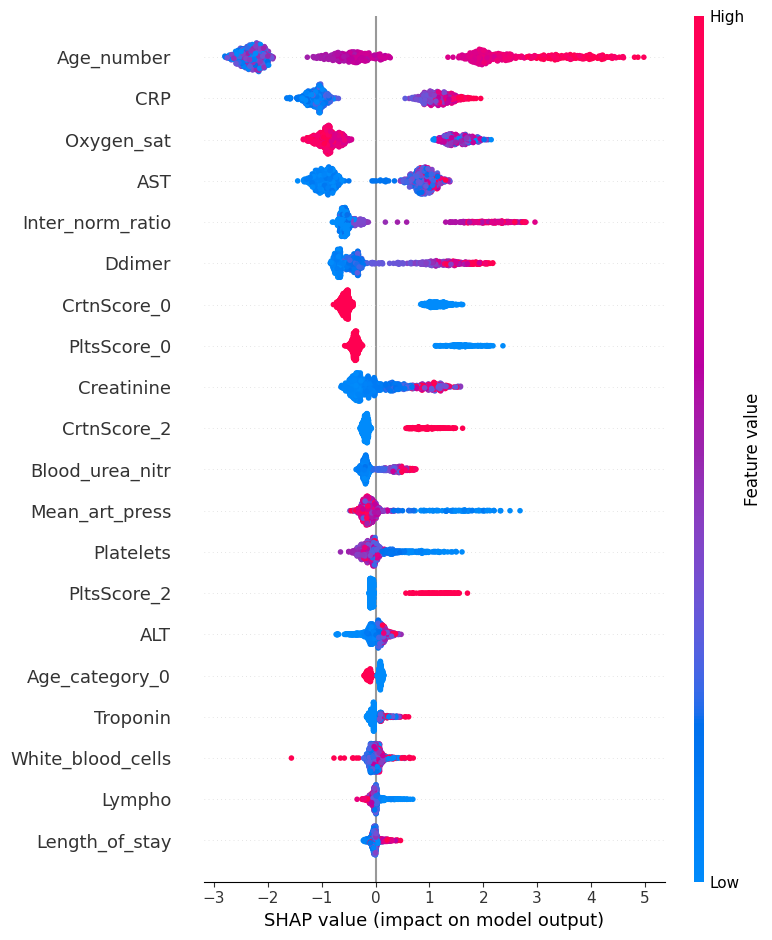

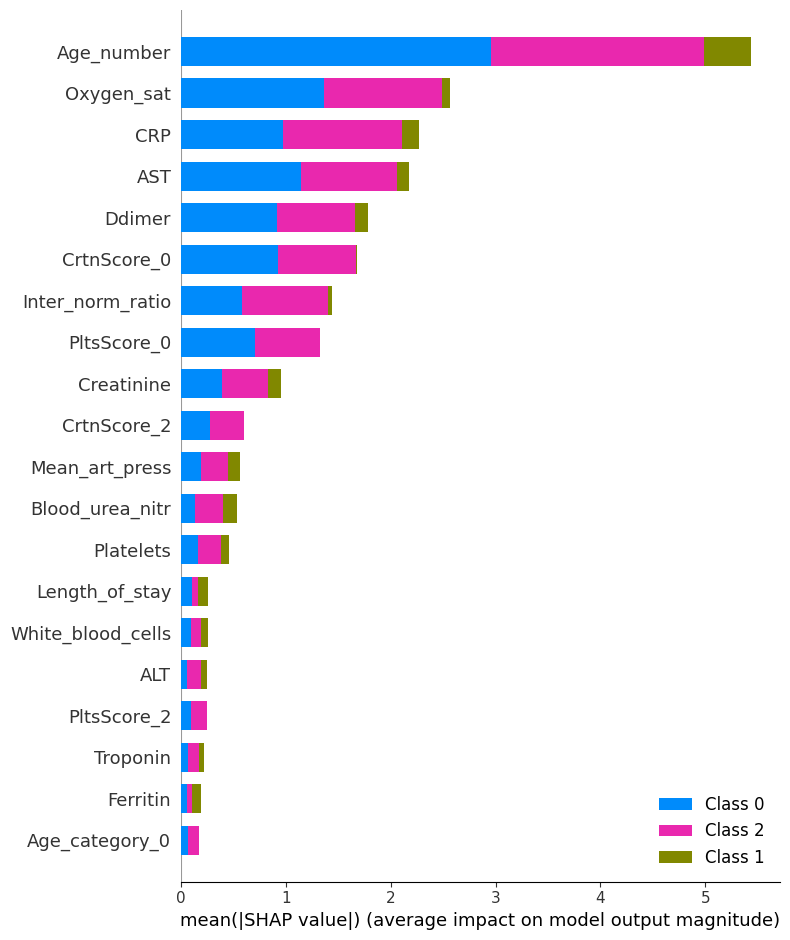

In [71]:
lgb = LGBMClassifier(learning_rate=0.1, max_depth=-1, n_estimators= 350, num_leaves=8)
lgb.fit(train_x, train_y)
pred = lgb.predict(test_x)

# Predict probabilities
y_prob = lgb.predict_proba(test_x)

print(classification_report(pred, test_y))
accuracy = accuracy_score(test_y, pred)
print(f"Accuracy on Test set: {accuracy}")

# Create object that can calculate shap values
explainer = shap.TreeExplainer(lgb)


shap_values = explainer.shap_values(test_x)

# Make plot.
shap.summary_plot(shap_values[2], test_x)
shap.summary_plot(shap_values, test_x)


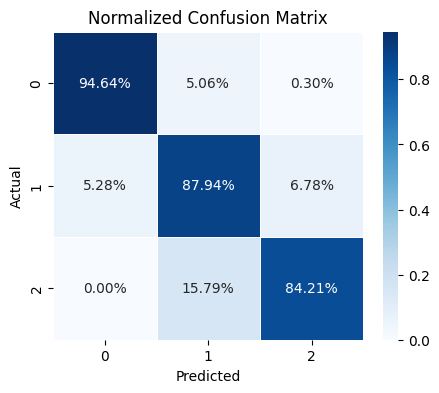

In [56]:
from sklearn.metrics import confusion_matrix

num_classes = 3

cm = confusion_matrix(test_y, pred)
# Convert confusion matrix to a DataFrame for better visualization
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row
cm_df = pd.DataFrame(cm_percentage, index=range(num_classes), columns=range(num_classes))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='.2%', cmap='Blues', linewidths=.5)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Fit and save same scaler scaler, but fitted only on the top features from original dataset

In [58]:
import joblib

# Select the columns we want to normalize
columns_to_normalize = top_features_list

# Create a new df for the columns to normalize
data_to_normalize = original_data[columns_to_normalize]

columns_order = ['Age_number', 'Oxygen_sat', 'CRP', 'AST', 'Ddimer',  'Inter_norm_ratio', 'Creatinine', 'Platelets']

# Reorder the df columns
data_to_normalize = data_to_normalize[columns_order]

scaler = MinMaxScaler()
scaler.fit(data_to_normalize)

# Save the scaler
joblib.dump(scaler, 'scaler_severity.pkl')

['scaler_severity.pkl']

## Uložiť najlepší model ako .pkl

In [72]:
import joblib

# Save the trained model to a file
joblib.dump(lgb, 'lgb_severity.pkl')

['lgb_severity.pkl']